In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
from PIL import Image
from IPython.display import display
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import StepLR
from torchsummary import summary
from tqdm import tqdm
import numpy 

In [ ]:
# Creating a function to  get the list of files
def get_list_of_files(dir_name):

    files_list = os.listdir(dir_name)

    return files_list


files_list_chest_xray_train = get_list_of_files("/Users/vinni/Desktop/ Lung Disease Detection/model_1_dataset/train/chest_xray")
files_list_Others_train = get_list_of_files("/Users/vinni/Desktop/ Lung Disease Detection/model_1_dataset/train/Others")
files_list_chest_xray_test = get_list_of_files("/Users/vinni/Desktop/ Lung Disease Detection/model_1_dataset/test/chest_xray")
files_list_Others_test = get_list_of_files("/Users/vinni/Desktop/ Lung Disease Detection/model_1_dataset/test/Others")

In [3]:
print(f"Number of train samples in chest_xray category {len(files_list_chest_xray_train)}")
print(f"Number of train samples in Others category {len(files_list_Others_train)}")
print(f"Number of test samples in chest_xray category {len(files_list_chest_xray_test)}")
print(f"Number of test samples in Others category {len(files_list_Others_test)}")

Number of train samples in chest_xray category 4686
Number of train samples in Others category 5281
Number of test samples in chest_xray category 1172
Number of test samples in Others category 1321


(240, 240)


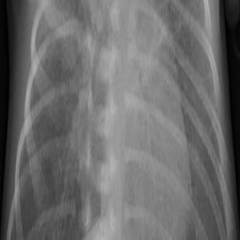

(240, 240)


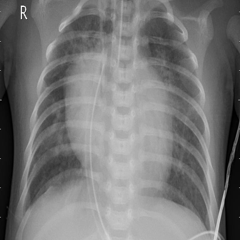

(240, 240)


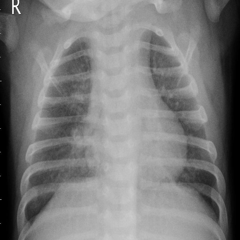

In [10]:
rand = np.random.randint(0,len(files_list_chest_xray_train),3)
for i in rand:
    path = "/Users/vinni/Desktop/ Lung Disease Detection/model_1_dataset/train/chest_xray/" + files_list_chest_xray_train[i]
    img = Image.open(path)
    img = img.resize((240,240))
    print(img.size)
    display(img)

# as u can see , diff images have diff-diff shape so for our model we have to resize all, to the same size

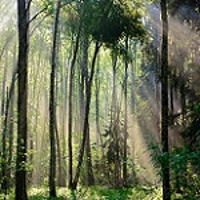

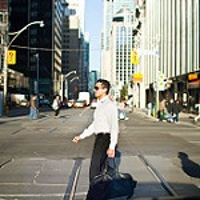

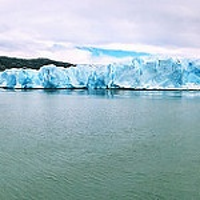

In [8]:
rand = np.random.randint(0,len(files_list_Others_train),3)
for i in rand:
    path = "/Users/vinni/Desktop/ Lung Disease Detection/model_1_dataset/train/Others/" + files_list_Others_train[i]
    img = Image.open(path)
    img = img.resize((240,240))
    display(img)

In [11]:
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    # Data Augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225])
])


In [12]:
data_path = "/Users/vinni/Desktop/ Lung Disease Detection/model_1_dataset"
train_data = datasets.ImageFolder(os.path.join(data_path, 'train'), transform= train_transform)
test_data = datasets.ImageFolder(os.path.join(data_path, 'test'), transform= test_transform)
train_loader = DataLoader(train_data,
                          batch_size= 32, shuffle= True, pin_memory= True)
test_loader = DataLoader(test_data,
                         batch_size= 32, shuffle= False, pin_memory= True)
class_names = train_data.classes
print(class_names)
print(f'Number of train images: {len(train_data)}')
print(f'Number of test images: {len(test_data)}')

['Others', 'chest_xray']
Number of train images: 9965
Number of test images: 2491


In [17]:
class Net_1(nn.Module):
    def __init__(self):
        """
        Creating custom CNN architecture for Image classification
        """
        super(Net_1, self).__init__()
        # Input Block
        self.convolution_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=(3, 3),
                      padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(8)
        )
        self.pooling11 = nn.MaxPool2d(2, 2)
        # CONVOLUTION BLOCK 1
        self.convolution_block2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=20, kernel_size=(3, 3),
                      padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(20)
        )
        self.pooling22 = nn.MaxPool2d(2, 2)
        self.convolution_block3 = nn.Sequential(
            nn.Conv2d(in_channels=20, out_channels=10, kernel_size=(1, 1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10),
        )
        self.pooling33 = nn.MaxPool2d(2, 2)
        # CONVOLUTION BLOCK 2
        self.convolution_block4 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=20, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(20) 
        )
        self.convolution_block5 = nn.Sequential(
            nn.Conv2d(in_channels=20, out_channels=32, kernel_size=(1, 1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(32),
        )
#         self.convblock6 = nn.Sequential(
#             nn.Conv2d(in_channels=32, out_channels=10, kernel_size=(1, 1), padding='same', bias=True),
#             nn.ReLU(),
#             nn.BatchNorm2d(10),
#         )
        self.convolution_block6 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=10, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
#         self.convblock8 = nn.Sequential(
#             nn.Conv2d(in_channels=10, out_channels=32, kernel_size=(1, 1), padding='same', bias=True),
#             nn.ReLU(),
#             nn.BatchNorm2d(32)
#         )
        self.convolution_block7 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=(1, 1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
        self.convolution_block8 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=14, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(14)
        )
        self.convolution_block9 = nn.Sequential(
            nn.Conv2d(in_channels=14, out_channels=16, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(16)
        )
        # OUTPUT BLOCK
        self.gap = nn.Sequential(
            nn.AvgPool2d(kernel_size=4)
        )
        self.convolution_block_out = nn.Sequential(
              nn.Conv2d(in_channels=16, out_channels=2, kernel_size=(4, 4), padding=0, bias=True),
        )
    def forward(self, x):
        x = self.convolution_block1(x)
        x = self.pooling11(x)
        x = self.convolution_block2(x)
        x = self.pooling22(x)
        x = self.convolution_block3(x)
        x = self.pooling33(x)
        x = self.convolution_block4(x)
        x = self.convolution_block5(x)
        x = self.convolution_block6(x)
        x = self.convolution_block7(x)
        x = self.convolution_block8(x)
        x = self.convolution_block9(x)
        # Global Average pooling
        x = self.gap(x)
        x = self.convolution_block_out(x)
        x = x.view(-1, 2) # reshape 2D matrix to 1d vector
        return F.log_softmax(x, dim=-1) # binary classification

In [18]:
import torch
from torchsummary import summary

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Available processor:", device)

# Model MPS par
model_1 = Net_1().to(device)

# Summary CPU par
summary(model_1.cpu(), input_size=(3, 224, 224)) # as summary only support the CUDA or CPU not mps

Available processor: mps
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             224
              ReLU-2          [-1, 8, 222, 222]               0
       BatchNorm2d-3          [-1, 8, 222, 222]              16
         MaxPool2d-4          [-1, 8, 111, 111]               0
            Conv2d-5         [-1, 20, 109, 109]           1,460
              ReLU-6         [-1, 20, 109, 109]               0
       BatchNorm2d-7         [-1, 20, 109, 109]              40
         MaxPool2d-8           [-1, 20, 54, 54]               0
            Conv2d-9           [-1, 10, 54, 54]             210
             ReLU-10           [-1, 10, 54, 54]               0
      BatchNorm2d-11           [-1, 10, 54, 54]              20
        MaxPool2d-12           [-1, 10, 27, 27]               0
           Conv2d-13           [-1, 20, 25, 25]           1,820
             R

In [19]:
train_losses = []
test_losses = []
train_acc = []
test_acc = []
def train(model_1, device, train_loader, optimizer, epoch):
    """
    Description: To train the model 
    
    input: model,device,train_loader,optimizer,epoch 
    
    output: loss, batch id and accuracy
    """
    model_1.train()
    pbar = tqdm(train_loader)
    correct = 0
    processed = 0
    for batch_idx, (data, target) in enumerate(pbar):
        # get data
        data, target = data.to(device), target.to(device)
        # Initialization of gradient
        optimizer.zero_grad()
        # In PyTorch, gradient is accumulated over backprop and even though thats used in RNN generally not used in CNN
        # or specific requirements
        ## prediction on data
        y_pred = model_1(data)
        # Calculating loss given the prediction
        loss = F.nll_loss(y_pred, target)
        train_losses.append(loss)
        # Backprop
        loss.backward()
        optimizer.step()
        # get the index of the log-probability corresponding to the max value
        pred = y_pred.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        processed += len(data)
        pbar.set_description(desc= f'Loss={loss.item()} Batch_id={batch_idx} Accuracy={100*correct/processed:0.2f}')
        train_acc.append(100*correct/processed)
def test(model_1, device, test_loader):
    """
    Description: To test the model
    
    input: model, device, test_loader
    
    output: average loss and accuracy
    
    """
    model_1.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model_1(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
            test_loss, correct, len(test_loader.dataset),
            100. * correct / len(test_loader.dataset)))
    test_acc.append(100. * correct / len(test_loader.dataset))

In [23]:
# Defining the params for training 
model_1 =  Net_1().to(device)
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.01, momentum=0.8)
scheduler = StepLR(optimizer, step_size=6, gamma=0.5)
EPOCHS = 25
# Training the model
for epoch in range(EPOCHS):
    print("EPOCH:", epoch)
    train(model_1, device, train_loader, optimizer, epoch)
    scheduler.step()
    print('current Learning Rate: ', optimizer.state_dict()["param_groups"][0]["lr"])
    test(model_1, device, test_loader)

EPOCH: 0


  0%|          | 0/312 [00:00<?, ?it/s]/Users/vinni/Desktop/ Lung Disease Detection/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Loss=0.0005611787782981992 Batch_id=311 Accuracy=98.17: 100%|██████████| 312/312 [00:42<00:00,  7.29it/s]


current Learning Rate:  0.01

Test set: Average loss: 0.0067, Accuracy: 2487/2491 (99.84%)

EPOCH: 1


Loss=9.011597285280004e-05 Batch_id=311 Accuracy=99.80: 100%|██████████| 312/312 [00:43<00:00,  7.19it/s] 


current Learning Rate:  0.01

Test set: Average loss: 0.0020, Accuracy: 2490/2491 (99.96%)

EPOCH: 2


...

current Learning Rate:  0.00125

Test set: Average loss: 0.0010, Accuracy: 2490/2491 (99.96%)

EPOCH: 23


Loss=0.006766123231500387 Batch_id=311 Accuracy=99.98: 100%|██████████| 312/312 [00:52<00:00,  5.95it/s]  


current Learning Rate:  0.000625

Test set: Average loss: 0.0012, Accuracy: 2490/2491 (99.96%)

EPOCH: 24


Loss=6.441831646952778e-05 Batch_id=311 Accuracy=99.97: 100%|██████████| 312/312 [00:56<00:00,  5.49it/s] 


current Learning Rate:  0.000625

Test set: Average loss: 0.0011, Accuracy: 2490/2491 (99.96%)



Text(0.5, 1.0, 'Test Accuracy Model_1')

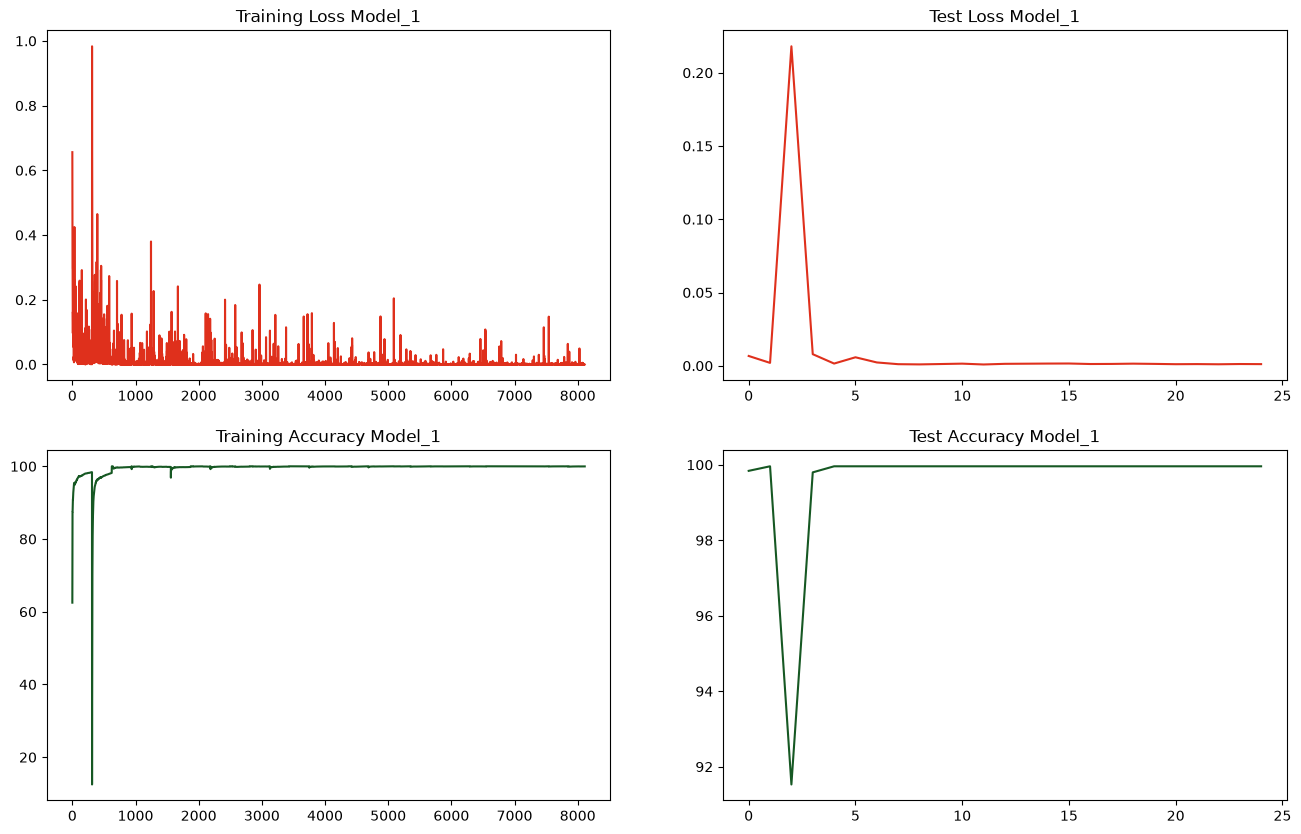

In [25]:
train_losses1 = [float(i.cpu().detach().numpy()) for i in train_losses]
train_acc1 = [i for i in train_acc]
test_losses1 = [i for i in test_losses]
test_acc1 = [i for i in test_acc]
fig, axs = plt.subplots(2,2,figsize=(16,10))
axs[0, 0].plot(train_losses1,color = "#DF301C")
axs[0, 0].set_title("Training Loss Model_1")
axs[1, 0].plot(train_acc1,color = "#165823")
axs[1, 0].set_title("Training Accuracy Model_1")
axs[0, 1].plot(test_losses1,color = "#DF301C")
axs[0, 1].set_title("Test Loss Model_1")
axs[1, 1].plot(test_acc1,color = "#165823")
axs[1, 1].set_title("Test Accuracy Model_1")


In [26]:
data_path = "/Users/vinni/Desktop/ Lung Disease Detection/model_1_dataset"
train_data = datasets.ImageFolder(os.path.join(data_path, 'train'), transform= train_transform)
test_data = datasets.ImageFolder(os.path.join(data_path, 'test'), transform= test_transform)
train_loader = DataLoader(train_data,
                          batch_size= 32, shuffle= True, pin_memory= True)
test_loader = DataLoader(test_data,
                         batch_size= 32, shuffle= True, pin_memory= True)
class_names = train_data.classes
print(class_names)
print(f'Number of train images: {len(train_data)}')
print(f'Number of test images: {len(test_data)}')

['Others', 'chest_xray']
Number of train images: 9965
Number of test images: 2491


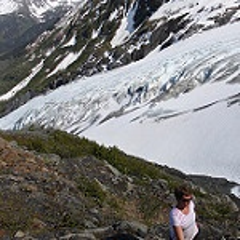

In [61]:
img = Image.open("/Users/vinni/Desktop/ Lung Disease Detection/model_1_dataset/test/Others/7678.jpg")
img = img.resize((240,240))
display(img)

In [62]:
img = test_transform(img)

img = img.unsqueeze(0)

# Move image to MPS
img = img.to(device)

model_1.eval()

with torch.no_grad():
    output = model_1(img)

probabilities = torch.exp(output)

confidence, predicted_class = torch.max(probabilities, dim=1)

class_names = ["Others", "chest_xray"]

prediction = class_names[predicted_class.item()]

print("Prediction:", prediction)
print("Confidence:", confidence.item() * 100, "%")

Prediction: Others
Confidence: 99.99995231628418 %


In [63]:
torch.save(
    model_1.state_dict(),
    "/Users/vinni/Desktop/ Lung Disease Detection/models/xray_detector.pth"

)